In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
# Load by file name
R2502_2504 = pd.read_pickle("R2502_2504.pkl")
R2504_2502 = pd.read_pickle("R2504_2502.pkl")
F2504 = pd.read_pickle("2504.pkl")

In [24]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-E")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-E2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-E*DIFF-PRESS-15min.txt"):
    print("found:", p.name)


/home/seismic/AxialFetch/MJ03F-E → True (dir)
/home/seismic/AxialFetch/MJ03F-E/MJ03F-E2022DIFF-PRESS-15min.txt → True
found: MJ03F-E2023DIFF-PRESS-15min.txt
found: MJ03F-E2022DIFF-PRESS-15min.txt
found: MJ03F-E2021DIFF-PRESS-15min.txt
found: MJ03F-E2020DIFF-PRESS-15min.txt
found: MJ03F-E2019DIFF-PRESS-15min.txt
found: MJ03F-E2018DIFF-PRESS-15min.txt
found: MJ03F-E2017DIFF-PRESS-15min.txt
found: MJ03F-E2016DIFF-PRESS-15min.txt
found: MJ03F-E2015DIFF-PRESS-15min.txt
found: MJ03F-E2014DIFF-PRESS-15min.txt
found: MJ03F-E2024DIFF-PRESS-15min.txt


In [25]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['central_p']= (cp['depth']/0.67)*6.89476

In [26]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
ep = pd.concat(df_list, ignore_index=True).sort_values('time')

ep['time'] = pd.to_datetime(ep['time'])
ep['central_p']= (ep['depth']/0.67)*6.89476

(19236.0, 20362.0)

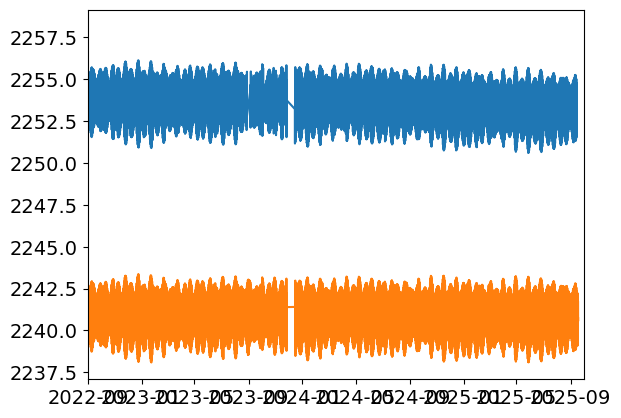

In [27]:
plt.plot(cp['time'],cp['rawpsi'])
plt.plot(ep['time'],ep['rawpsi'])
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2025, 10, 1, tz="UTC"))

In [28]:
import pandas as pd

# ---------- 1) Safe copies + time parsing ----------
cp_ = cp.copy()
ep_ = ep.copy()

cp_["time"] = pd.to_datetime(cp_["time"], errors="coerce")
ep_["time"] = pd.to_datetime(ep_["time"], errors="coerce")

# If any timezone info sneaks in, strip to naive (optional but robust)
for df in (cp_, ep_):
    try:
        df["time"] = df["time"].dt.tz_convert(None)
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None)
        except Exception:
            pass

# OPTIONAL: If cadence is fixed (e.g., 15 s) but tiny jitter exists, enable rounding:
# cp_["time"] = cp_["time"].dt.round("15s")
# ep_["time"] = ep_["time"].dt.round("15s")

# Ensure numeric types
for col in ["rawpsi", "depth"]:
    cp_[col] = pd.to_numeric(cp_[col], errors="coerce")
    ep_[col] = pd.to_numeric(ep_[col], errors="coerce")

cp_ = cp_.dropna(subset=["time", "rawpsi", "depth"])
ep_ = ep_.dropna(subset=["time", "rawpsi", "depth"])

# ---------- 2) Align by time and compute cp - ep for pressure and depth ----------
diff_df = pd.merge(
    cp_[["time", "rawpsi", "depth"]],
    ep_[["time", "rawpsi", "depth"]],
    on="time",
    how="inner",
    suffixes=("_cp", "_ep"),
)

# Differences (cp - ep)
diff_df["rawpsi_cp_minus_ep"] = diff_df["rawpsi_cp"] - diff_df["rawpsi_ep"]
diff_df["depth_cp_minus_ep"]  = diff_df["depth_cp"]  - diff_df["depth_ep"]

# ---------- 3) Daily means (separate dataframe) ----------
daily_df = (
    diff_df.set_index("time")[["rawpsi_cp_minus_ep", "depth_cp_minus_ep"]]
           .resample("1D")
           .mean()
           .reset_index()
           .rename(columns={
               "rawpsi_cp_minus_ep": "pressure_diff",
               "depth_cp_minus_ep":  "depth_m"
           })
)


In [29]:
daily_df

,time,pressure_diff,depth_m
0,2016-01-01,14.143040,9.476331
1,2016-01-02,14.140357,9.473884
2,2016-01-03,14.137693,9.471475
3,2016-01-04,14.136605,9.470275
4,2016-01-05,14.135539,9.469345
...,...,...,...
3541,2025-09-11,12.465623,8.350836
3542,2025-09-12,12.466299,8.350896
3543,2025-09-13,12.466830,8.351197
3544,2025-09-14,12.459020,8.346284


In [31]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2022, 2025)      # 2022-2024
factor    = 1.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ---------------------------------------------------------------------


Rows in df_pressure: 1020


In [32]:
import pandas as pd

# --- normalize times ---
d1 = df_1day.copy()
d2 = daily_df.copy()

for d in (d1, d2):
    d["time"] = pd.to_datetime(d["time"], errors="coerce")
    try:
        d["time"] = d["time"].dt.tz_convert(None)
    except Exception:
        try:
            d["time"] = d["time"].dt.tz_localize(None)
        except Exception:
            pass
    d["time"] = d["time"].dt.floor("D")

# --- match column names and keep only new tail days ---
d2 = d2.rename(columns={
    "rawpsi_cp_minus_ep_mean": "pressure_diff",
    "depth_cp_minus_ep_mean":  "depth_m",
})
last_day = d1["time"].max()
tail = d2[d2["time"] > last_day][["time", "pressure_diff", "depth_m"]]

# --- extend df_1day IN PLACE ---
df_1day = (
    pd.concat([d1[["time", "pressure_diff", "depth_m"]], tail], ignore_index=True)
      .drop_duplicates(subset=["time"], keep="last")
      .sort_values("time")
      .reset_index(drop=True)
)

# Optional sanity check:
# print("New df_1day range:", df_1day["time"].min().date(), "→", df_1day["time"].max().date())
# df_1day.tail()


In [33]:
df_1day = daily_df

In [34]:
df_1day

,time,pressure_diff,depth_m
0,2016-01-01,14.143040,9.476331
1,2016-01-02,14.140357,9.473884
2,2016-01-03,14.137693,9.471475
3,2016-01-04,14.136605,9.470275
4,2016-01-05,14.135539,9.469345
...,...,...,...
3541,2025-09-11,12.465623,8.350836
3542,2025-09-12,12.466299,8.350896
3543,2025-09-13,12.466830,8.351197
3544,2025-09-14,12.459020,8.346284


Outliers removed: 208 points


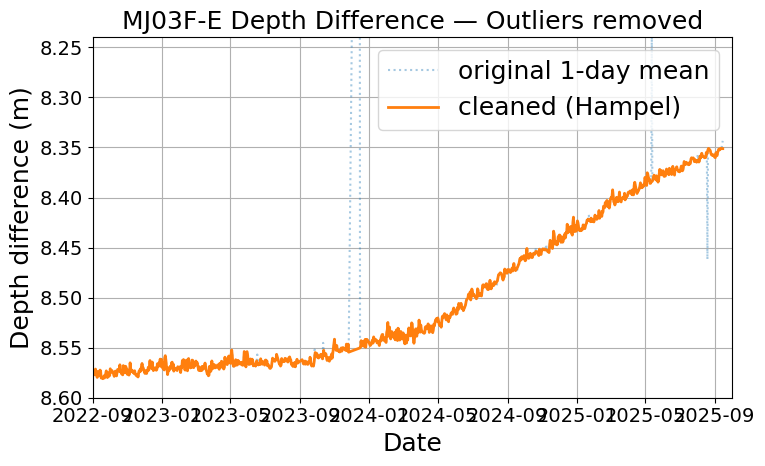

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1) Hampel helper ----
def hampel_outliers(s: pd.Series, window:int=9, n_sigmas:float=4.5) -> pd.Series:
    """Return a boolean mask of outliers using a rolling median + MAD."""
    med = s.rolling(window, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=1).median()
    # Consistent estimator for std under normality
    sigma = 1.4826 * mad
    return (s - med).abs() > n_sigmas * sigma

# ---- 2) Clean the series ----
df = df_1day.copy()

# Ensure proper dtypes and ordering
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
df = df.dropna(subset=["time", "depth_m"]).sort_values("time").set_index("time")

# Detect and remove outliers
mask = hampel_outliers(df["depth_m"], window= 9, n_sigmas=4.5)
df["depth_m_no_out"] = df["depth_m"].where(~mask)

# Optional: fill removed spikes by time interpolation (or leave as NaN if you prefer)
df["depth_m_clean"] = (
    df["depth_m_no_out"]
    .interpolate(method="time", limit_direction="both")
)

print(f"Outliers removed: {mask.sum()} points")

# ---- 3) Plot ----
plt.figure(figsize=(8, 5))
# Original (light, dotted)
plt.plot(df.index, df["depth_m"], linestyle=":", alpha=0.4, label="original 1-day mean")
# Cleaned (thicker)
plt.plot(df.index, df["depth_m_clean"], linewidth=2, label="cleaned (Hampel)")

plt.gca().invert_yaxis()
plt.xlabel("Date"); plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference — Outliers removed")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"), pd.Timestamp(2025, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.24)
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# If you want to keep the cleaned series back in df_1day:
df_1day = df.reset_index().rename(columns={"depth_m_clean": "depth_m"})


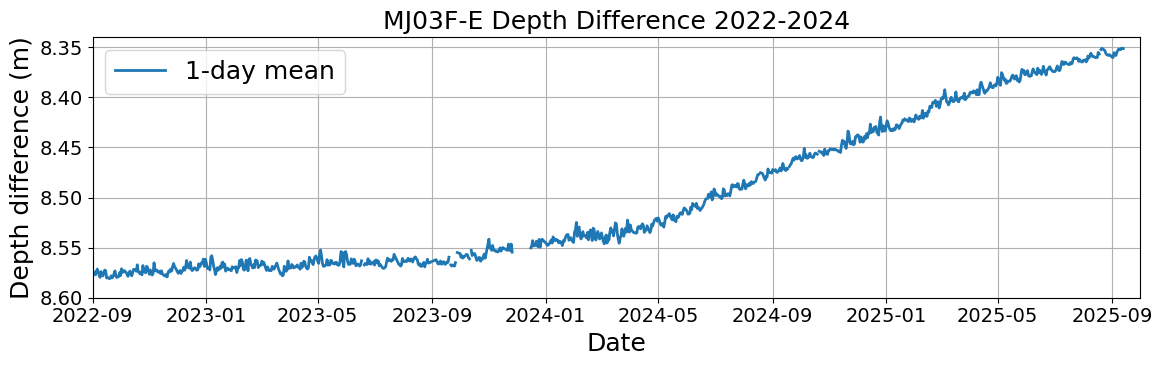

In [36]:
plt.figure(figsize=(12, 4))
plt.rcParams.update({
    "font.size": 18,           # base
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 18,
})
plt.plot(df_1day["time"],  df_1day["depth_m_no_out"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2025, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.34)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


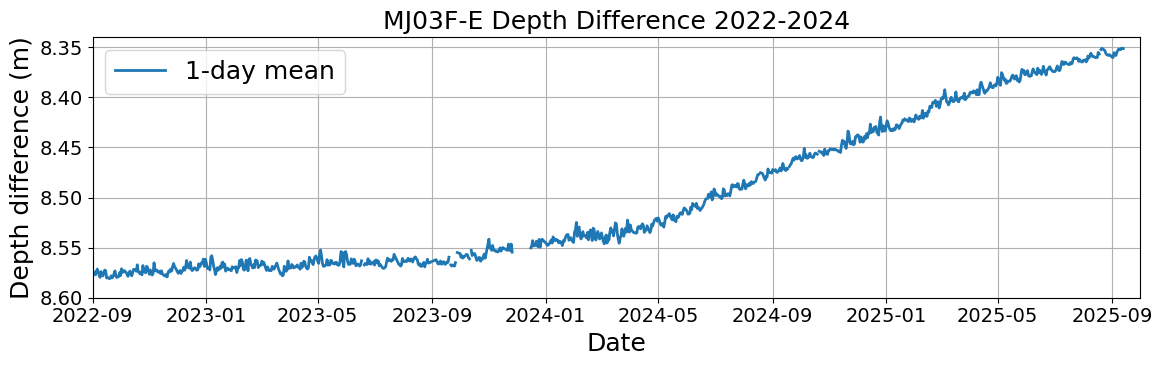

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# ====================================================================
# 1) LOAD RAW CP AND EP DATA
# ====================================================================
# Load CP (central) data
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03F*.Data")
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)
cp = pd.concat(df_list, ignore_index=True).sort_values('time')
cp['time'] = pd.to_datetime(cp['time'])

# Load EP (edge) data
file_paths = glob.glob("/data/wsd02/maleen_data/MJ03E*.Data")
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)
ep = pd.concat(df_list, ignore_index=True).sort_values('time')
ep['time'] = pd.to_datetime(ep['time'])

# ====================================================================
# 2) ALIGN AND COMPUTE DIFFERENCES
# ====================================================================
cp_ = cp.copy()
ep_ = ep.copy()

cp_["time"] = pd.to_datetime(cp_["time"], errors="coerce")
ep_["time"] = pd.to_datetime(ep_["time"], errors="coerce")

# Strip timezone
for df in (cp_, ep_):
    try:
        df["time"] = df["time"].dt.tz_convert(None)
    except Exception:
        try:
            df["time"] = df["time"].dt.tz_localize(None)
        except Exception:
            pass

# Ensure numeric
for col in ["rawpsi", "depth"]:
    cp_[col] = pd.to_numeric(cp_[col], errors="coerce")
    ep_[col] = pd.to_numeric(ep_[col], errors="coerce")

cp_ = cp_.dropna(subset=["time", "rawpsi", "depth"])
ep_ = ep_.dropna(subset=["time", "rawpsi", "depth"])

# Merge on time
diff_df = pd.merge(
    cp_[["time", "rawpsi", "depth"]],
    ep_[["time", "rawpsi", "depth"]],
    on="time",
    how="inner",
    suffixes=("_cp", "_ep"),
)

diff_df["depth_cp_minus_ep"] = diff_df["depth_cp"] - diff_df["depth_ep"]

# ====================================================================
# 3) DAILY RESAMPLING
# ====================================================================
daily_df = (
    diff_df.set_index("time")[["depth_cp_minus_ep"]]
           .resample("1D")
           .mean()
           .reset_index()
           .rename(columns={"depth_cp_minus_ep": "depth_m"})
)

df_1day = daily_df

# ====================================================================
# 4) OUTLIER REMOVAL (HAMPEL)
# ====================================================================
def hampel_outliers(s: pd.Series, window: int = 9, n_sigmas: float = 4.5) -> pd.Series:
    """Return boolean mask of outliers using rolling median + MAD."""
    med = s.rolling(window, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=1).median()
    sigma = 1.4826 * mad
    return (s - med).abs() > n_sigmas * sigma

df = df_1day.copy()
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
df = df.dropna(subset=["time", "depth_m"]).sort_values("time").set_index("time")
mask = hampel_outliers(df["depth_m"], window=9, n_sigmas=4.5)
df["depth_m_no_out"] = df["depth_m"].where(~mask)
df_1day = df.reset_index()

# ====================================================================
# 5) PLOT
# ====================================================================
plt.figure(figsize=(12, 4))
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 18,
})
plt.plot(df_1day["time"], df_1day["depth_m_no_out"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2025, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.34)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [199]:
df_1day["depth_m_no_out"][0]-df_1day["depth_m_no_out"][3424]

1.1251343471445896

In [201]:
df_1day

,time,pressure_diff,depth_m,depth_m_no_out,depth_m
0,2016-01-01 00:00:00+00:00,14.143040,9.476331,9.476331,9.476331
1,2016-01-02 00:00:00+00:00,14.140357,9.473884,9.473884,9.473884
2,2016-01-03 00:00:00+00:00,14.137693,9.471475,9.471475,9.471475
3,2016-01-04 00:00:00+00:00,14.136605,9.470275,9.470275,9.470275
4,2016-01-05 00:00:00+00:00,14.135539,9.469345,9.469345,9.469345
...,...,...,...,...,...
3422,2025-09-11 00:00:00+00:00,12.465623,8.350836,8.350836,8.350836
3423,2025-09-12 00:00:00+00:00,12.466299,8.350896,8.350896,8.350896
3424,2025-09-13 00:00:00+00:00,12.466830,8.351197,8.351197,8.351197
3425,2025-09-14 00:00:00+00:00,12.459020,8.346284,NaN,8.351197


In [169]:
cp

,time,rawpsi,depth,temp,central_p
5677936,2016-01-01 00:00:00,2256.901400,1511.627900,2.777386,15555.688925
5677937,2016-01-01 00:00:15,2256.896600,1511.624600,2.777327,15555.654966
5677938,2016-01-01 00:00:30,2256.891800,1511.621200,2.777256,15555.619977
5677939,2016-01-01 00:00:45,2256.892700,1511.621700,2.777218,15555.625123
5677940,2016-01-01 00:01:00,2256.893700,1511.622100,2.777155,15555.629239
...,...,...,...,...,...
19357222,2025-09-15 00:27:00,2254.769943,1509.714562,2.784791,15535.999362
19357223,2025-09-15 00:27:15,2254.770865,1509.714780,2.784802,15536.001604
19357224,2025-09-15 00:27:30,2254.771606,1509.714876,2.784792,15536.002592
19357225,2025-09-15 00:27:45,2254.774897,1509.716581,2.784804,15536.020141


In [144]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2502_2504, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------

# distance opposite direction d2
d2 = to_series(R2504_2502, "Record Time", "Moving Average")


# -- 1. create dp (pressure-difference) --------------------------------------
dp = (
    df_pressure
        .assign(time=pd.to_datetime(df_pressure["time"], utc=True))
        .set_index("time")["pressure_diff"]
        .astype(float)
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="first")]
)

# -- 2. create cp1 (central pressure) ----------------------------------------
cp1 = (
    cp
        .assign(time=pd.to_datetime(cp["time"], utc=True))
        .set_index("time")["central_p"]
        .astype(float)
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="first")]
)

# -- 3. combine, align on common timestamps, compute p1 = cp1 – dp ----------
pressure_df = (
    pd.concat({"cp1": cp1, "dp": dp}, axis=1)   # align on DateTime index
      .dropna(subset=["cp1", "dp"])             # keep rows where BOTH exist
)

pressure_df["p1"] = pressure_df["cp1"] - (pressure_df["dp"]*6.89476)

# -- 4. tidy up columns -------------------------------------------------------
pressure_df.index.name = "Datetime"             # give index a name
pressure_df = pressure_df.reset_index()[["Datetime", "p1", "cp1"]]


In [145]:
p1 = to_series(pressure_df, "Datetime", "p1")
p2 = to_series(pressure_df, "Datetime", "cp1")

In [165]:
pressure_df

,Datetime,p1,cp1
0,2022-01-01 00:00:00+00:00,15451.763165,15540.320814
1,2022-01-02 00:00:00+00:00,15451.644131,15540.183948
2,2022-01-03 00:00:00+00:00,15451.553505,15540.068692
3,2022-01-04 00:00:00+00:00,15451.448355,15539.994599
4,2022-01-05 00:00:00+00:00,15451.773842,15540.318756
...,...,...,...
984,2024-12-27 00:00:00+00:00,15450.343030,15537.113207
985,2024-12-28 00:00:00+00:00,15450.473687,15537.278887
986,2024-12-29 00:00:00+00:00,15450.921589,15537.662729
987,2024-12-30 00:00:00+00:00,15450.963890,15537.738881


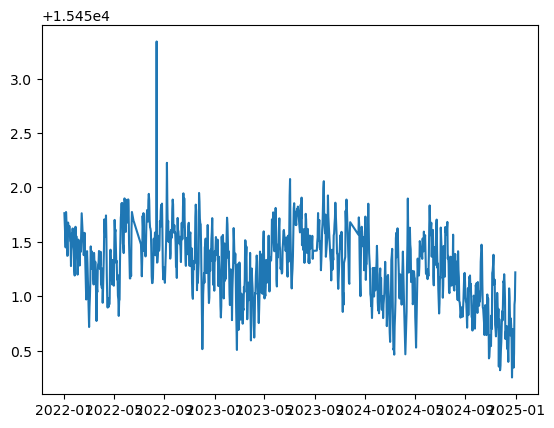

In [167]:
plt.plot(pressure_df['Datetime'],pressure_df['p1'])

In [147]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "d1", "d2"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [148]:
df_var

,Record Time,p1,p2,d1,d2
0,2022-09-01 15:30:00+00:00,15451.172039,15539.426210,164220.542867,NaN
1,2022-09-01 19:30:00+00:00,15451.148924,15539.407001,164220.246056,164218.836206
2,2022-09-01 23:30:00+00:00,15451.125810,15539.387792,164217.772635,164215.497087
3,2022-09-02 03:30:00+00:00,15451.138671,15539.400097,164217.871572,164216.214379
4,2022-09-02 07:30:00+00:00,15451.156671,15539.416906,164218.494874,164216.467905
...,...,...,...,...,...
5870,2025-08-08 11:30:00+00:00,15451.218812,15538.001293,164233.510969,164233.644547
5871,2025-08-08 15:30:00+00:00,15451.218812,15538.001293,164233.447630,164233.581619
5872,2025-08-08 19:30:00+00:00,15451.218812,15538.001293,164233.526984,164233.660974
5873,2025-08-08 23:30:00+00:00,15451.218812,15538.001293,164233.538463,164233.677400


In [149]:
df_var = df_var.dropna().reset_index(drop=True)

import pandas as pd

cutoff = pd.Timestamp(2022, 9, 7, tz="UTC")

# ensure 'time' is datetime and remove earlier rows
df_var["Record Time"] = pd.to_datetime(df_var["Record Time"], utc=True)
df_var = df_var[df_var["Record Time"] >= cutoff].reset_index(drop=True)


In [150]:
df_var['d1'] = df_var['d1']/100
df_var['d2'] = df_var['d2']/100
df_var

,Record Time,p1,p2,d1,d2
0,2022-09-07 03:30:00+00:00,15452.170597,15540.401939,1642.111901,1642.100617
1,2022-09-07 07:30:00+00:00,15452.107202,15540.342939,1642.109119,1642.097781
2,2022-09-07 19:30:00+00:00,15451.917019,15540.165939,1642.107209,1642.097323
3,2022-09-07 23:30:00+00:00,15451.853625,15540.106939,1642.105699,1642.095747
4,2022-09-08 03:30:00+00:00,15451.814298,15540.071350,1642.103126,1642.093348
...,...,...,...,...,...
5841,2025-08-08 11:30:00+00:00,15451.218812,15538.001293,1642.335110,1642.336445
5842,2025-08-08 15:30:00+00:00,15451.218812,15538.001293,1642.334476,1642.335816
5843,2025-08-08 19:30:00+00:00,15451.218812,15538.001293,1642.335270,1642.336610
5844,2025-08-08 23:30:00+00:00,15451.218812,15538.001293,1642.335385,1642.336774


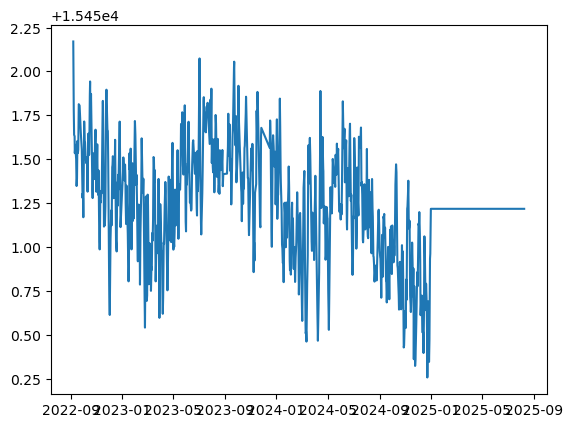

In [154]:
plt.plot(df_var['Record Time'], df_var['p1'])

Text(0.5, 1.0, 'Central - East Distance')

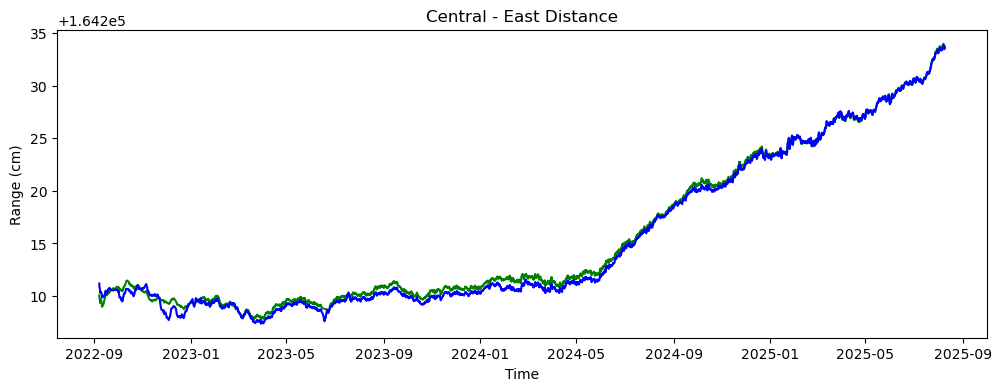

In [151]:
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'],df_var['d2']*100,"green")
plt.plot(df_var['Record Time'],df_var['d1']*100,"blue")
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Central - East Distance")

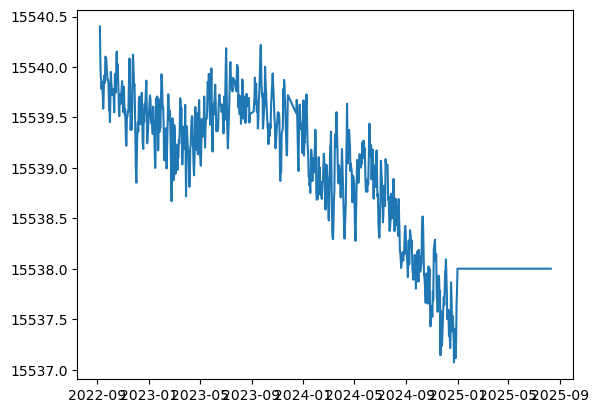

In [161]:
plt.plot(df_var['Record Time'],df_var['p2'].values )

In [162]:
df_var

,Record Time,p1,p2,d1,d2
0,2022-09-07 03:30:00+00:00,15452.170597,15540.401939,1642.111901,1642.100617
1,2022-09-07 07:30:00+00:00,15452.107202,15540.342939,1642.109119,1642.097781
2,2022-09-07 19:30:00+00:00,15451.917019,15540.165939,1642.107209,1642.097323
3,2022-09-07 23:30:00+00:00,15451.853625,15540.106939,1642.105699,1642.095747
4,2022-09-08 03:30:00+00:00,15451.814298,15540.071350,1642.103126,1642.093348
...,...,...,...,...,...
5841,2025-08-08 11:30:00+00:00,15451.218812,15538.001293,1642.335110,1642.336445
5842,2025-08-08 15:30:00+00:00,15451.218812,15538.001293,1642.334476,1642.335816
5843,2025-08-08 19:30:00+00:00,15451.218812,15538.001293,1642.335270,1642.336610
5844,2025-08-08 23:30:00+00:00,15451.218812,15538.001293,1642.335385,1642.336774


In [152]:
import numpy as np

#-------------------------------------------------
# 1) EXTRACT ARRAYS
#-------------------------------------------------
time = df_var['Record Time'].values
p1   = df_var['p1'].values          # East pressure (P)
p2   = df_var['p2'].values          # absolute pressure  (P)
r_CE = df_var['d1'].values          # range E → C
r_EC = df_var['d2'].values          # range C → E

#-------------------------------------------------
# 2) TIME → FLOAT DAYS
#-------------------------------------------------
t_days = (time - time[0]) / np.timedelta64(1, 'D')

#-------------------------------------------------
# 3) PERIODIC TERMS
#-------------------------------------------------
T_year = 365.25
ω      = 2.0 * np.pi / T_year
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

#-------------------------------------------------
# 4) STANDARDISE PRESSURES  (z-score keeps sign but removes offset)
#-------------------------------------------------
p1_std = (p1 - p1.mean()) #/ p1.std()
p2_std = (p2 - p2.mean()) #/ p2.std()

#-------------------------------------------------
# 5) DESIGN MATRIX  (N × 5)  with intercept
#     R(t) = C + a·p1_std + b·p2_std + c·sin + d·cos
#-------------------------------------------------
#A = np.column_stack([np.ones_like(p1), p1_std, p2_std, sin_t, cos_t])
A = np.column_stack([np.ones_like(p2), p2_std, sin_t, cos_t])
#-------------------------------------------------
# 6) LEAST-SQUARES FITS
#-------------------------------------------------
x_CE, *_ = np.linalg.lstsq(A, r_CE, rcond=None)   # (C_CE, a_CE, b_CE, c_CE, d_CE)
x_EC, *_ = np.linalg.lstsq(A, r_EC, rcond=None)   # (C_EC, a_EC, b_EC, c_EC, d_EC)

r_CE_fit = A @ x_CE
r_EC_fit = A @ x_EC

#-------------------------------------------------
# 7) RESULTS
#-------------------------------------------------
print("==== Range C→E coefficients ====")
print(f"C_CE (intercept) : {x_CE[0]:.6f}")
#print(f"a_CE (Pe std)    : {x_CE[1]:.6f}")
print(f"b_CE (Pc  std)    : {x_CE[1]:.6f}")
print(f"c_CE (annual sin): {x_CE[2]:.6f}")
print(f"d_CE (annual cos): {x_CE[3]:.6f}")

print("\n==== Range E→C coefficients ====")
print(f"C_EC (intercept) : {x_EC[0]:.6f}")
#print(f"a_EC (Pe std)    : {x_EC[1]:.6f}")
print(f"b_EC (Pc  std)    : {x_EC[1]:.6f}")
print(f"c_EC (annual sin): {x_EC[2]:.6f}")
print(f"d_EC (annual cos): {x_EC[3]:.6f}")


==== Range C→E coefficients ====
C_CE (intercept) : 1642.157633
b_CE (Pc  std)    : -0.089636
c_CE (annual sin): -0.014317
d_CE (annual cos): 0.011919

==== Range E→C coefficients ====
C_EC (intercept) : 1642.160941
b_EC (Pc  std)    : -0.087980
c_EC (annual sin): -0.013720
d_EC (annual cos): 0.011934


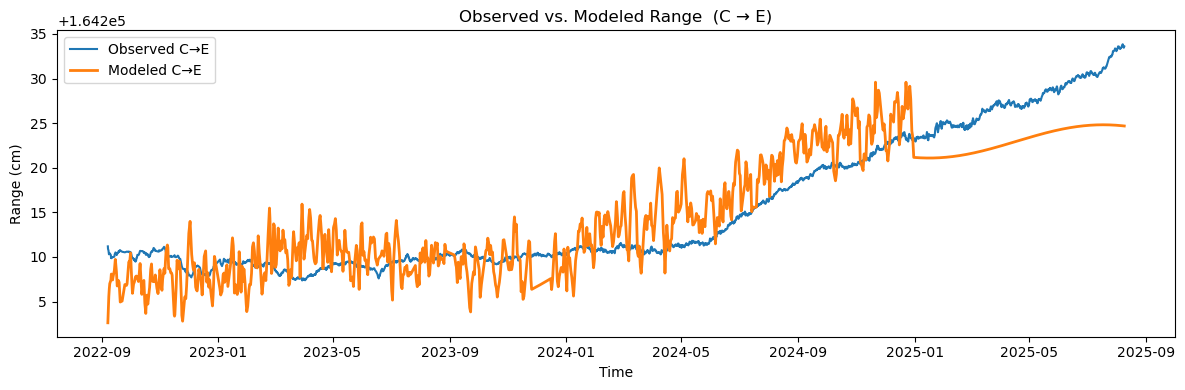

In [153]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 6)  OBSERVED vs. MODELED  –  RANGE W→C  (r_CE)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_CE*100,      label='Observed C→E')
plt.plot(df_var['Record Time'], r_CE_fit*100,  label='Modeled C→E', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Observed vs. Modeled Range  (C → E)")
plt.legend()
plt.tight_layout()
plt.show()

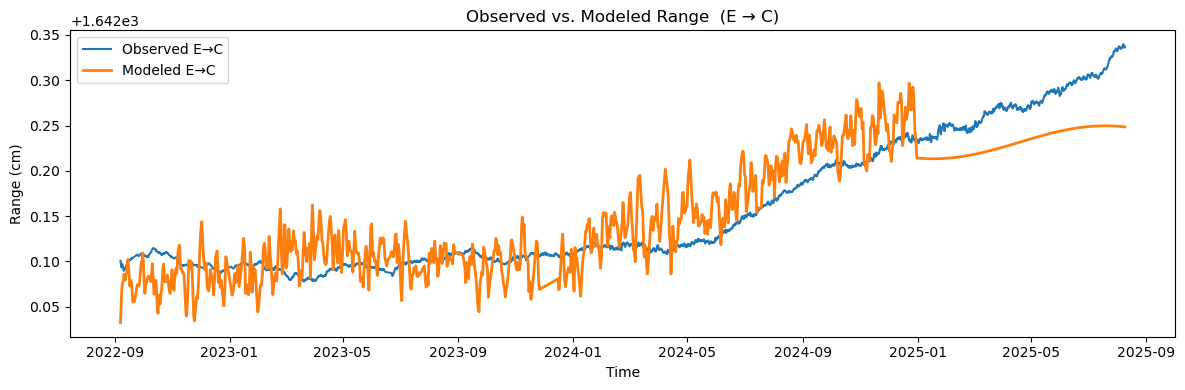

In [82]:
# ------------------------------------------------------------------
# 7)  OBSERVED vs. MODELED  –  RANGE C→W  (r_EC)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_EC,      label='Observed E→C')
plt.plot(df_var['Record Time'], r_EC_fit,  label='Modeled E→C', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Observed vs. Modeled Range  (E → C)")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
from sklearn.metrics import r2_score
print('R² (E→C) =', r2_score(r_EC,  r_EC_fit))
print('R² (C→E) =', r2_score(r_CE,  r_CE_fit))


R² (E→C) = 0.7741291379094188
R² (C→E) = 0.7692582050070386


In [84]:
import matplotlib.pyplot as plt
import numpy as np

# --- 8) SEASONAL CONTRIBUTION ---------------------------------------------
season_CE= x_CE[3] * sin_t + x_CE[4] * cos_t          #  d·sin + e·cos

# --- 9) DE-SEASONALISE -----------------------------------------------------
r_CE_deseas_fit  = r_CE_fit  - season_CE               # model     – seasonality
obs_deseas = r_CE  - season_CE                 # (leaves C + pressure terms)

# --- 10) PLOT --------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_CE,"red", label='Observed C→E ')
plt.plot(df_var['Record Time'], r_CE_deseas_fit,"green", label='Modeled C→E (no seasonal term)', linewidth=2)
plt.plot(df_var['Record Time'], obs_deseas, label='observed C→E (no seasonal)', linewidth=2)
#plt.axhline(0, color='k', lw=0.75, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Range residual (cm)")
#plt.title("C → E range with annual sine/cosine removed")
plt.legend()
plt.tight_layout()
plt.show()


IndexError: index 4 is out of bounds for axis 0 with size 4